## Finetuning YOLOv8-seg
On the gerbil dataset

In [1]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import glob
from ultralytics import YOLO

# %matplotlib notebook
matplotlib.use("module://matplotlib_inline.backend_inline")

### Visualizing Bounding Boxes

In [2]:
data_path = "data/Gerbil tracking test.v3i.yolov8/data.yaml"
train_path = "data/Gerbil tracking test.v3i.yolov8/train/"
test_path = "data/Gerbil tracking test.v3i.yolov8/test/"
val_path = "data/Gerbil tracking test.v3i.yolov8/val/"
# data/Gerbil tracking test.v3i.yolov8/train/labels/

In [3]:
import matplotlib
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


In [4]:
names=['adult_back', 'adult_front', 'pup_fluffy', 'pup_h_stripe', 'pup_spotted', 'pup_v_stripe']

In [5]:
import cv2

def store_annotated_image(image_path, label_path, output_path):

    plt.figure(figsize=(10,10))

    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        class_id = names[int(parts[0])]
        coords = np.array(parts[1:], dtype=float)

        # Convert to pixel coordinates
        coords[0::2] *= w   # x coords
        coords[1::2] *= h   # y coords

        points = coords.reshape(-1, 2).astype(int)

        # Random color
        color = np.random.randint(0, 255, 3)

        # Draw polygon
        cv2.polylines(img, [points], isClosed=True, color=color.tolist(), thickness=2)

        # Put label
        cv2.putText(img, f"{class_id}",
                    tuple(points[0]),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    color.tolist(),
                    2)

    cv2.imwrite(output_path, img)


In [ ]:
image_path = test_path + "images/center_frame_14400_jpg.rf.ec0105913067504e779db82f75699838.jpg"
label_path = test_path + "labels/center_frame_14400_jpg.rf.ec0105913067504e779db82f75699838.txt"


for image_path in glob.glob(test_path + "images/*.jpg"):
    label_path = image_path.replace("images", "labels").replace(".jpg", ".txt")
    output_path = test_path + "annotated_images/" + os.path.basename(image_path)
    # print(label_path, output_path)
    store_annotated_image(image_path, label_path, output_path)

In [6]:
from matplotlib.backends.backend_pdf import PdfPages
def get_comparison_pdf(pdf_path, predictions_folder):
    pp = PdfPages(pdf_path)
    for image_path in glob.glob(test_path + "annotated_images/*.jpg"):
        img = cv2.imread(image_path)
        output_path = predictions_folder+ os.path.basename(image_path)
        pred = cv2.imread(output_path)
        fig,ax = plt.subplots(1,2,figsize=(10,5))
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].axis("off")
        ax[1].imshow(cv2.cvtColor(pred, cv2.COLOR_BGR2RGB))
        ax[1].axis("off")
        pp.savefig(fig)
    pp.close()

### Model Training

In [53]:
# Load pretrained segmentation model
model = YOLO("yolov8s-seg.pt")  # you can use s, m, l, x versions
# model = YOLO("yolo26n-seg.pt")

In [54]:
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

True
True


In [55]:
# Train
model.train(
    data=data_path,
    epochs=60,
    imgsz=768,
    batch=8,
    device='mps',
    patience=15,
    workers=2,
    project="gerbil_training",
    name="yolov8s_seg_finetune_768",
    pretrained=True
)

Ultralytics 8.4.14 🚀 Python-3.11.0 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/Gerbil tracking test.v3i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_seg_finetune_7683, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

KeyboardInterrupt: 

In [11]:
## Trained model so far

# YOLOv8n-seg.pt with 2 epochs
yolov8_2epochs = "runs/segment/gerbil_training/yolov8_seg_finetune3_2pochs/weights/best.pt"

# YOLOv8n-seg.pt with 10 epochs
yolov8_10epochs = "runs/segment/gerbil_training/yolov8_seg_finetune4/weights/best.pt"

# YOLOv8n-seg.pt with 80 epochs
yolov8_80epochs = "runs/segment/gerbil_training/yolov8n_seg_finetune_80epochs/weights/best.pt"

# YOLOv8n-seg.pt with 60 epochs
yolov8n_60epochs = "runs/segment/gerbil_training/yolov8n_seg_finetune_60epochs/weights/best.pt"

# YOLOv8s-seg.pt with 80 epochs
yolov8s_80epochs = "runs/segment/gerbil_training/yolov8s_seg_finetune_80epochs/weights/best.pt"

# YOLOv8s-seg.pt with 80 epochs
yolov8s_80epochs_640 = "runs/segment/gerbil_training/yolov8s_seg_finetune_640/weights/best.pt"

In [12]:
model = YOLO(yolov8s_80epochs_640)

In [13]:
metrics = model.val(save=False, device="mps")
print(metrics)

Ultralytics 8.4.14 🚀 Python-3.11.0 torch-2.10.0 MPS (Apple M4)
YOLOv8s-seg summary (fused): 86 layers, 11,781,922 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 142.3±61.2 MB/s, size: 35.6 KB)
val: Scanning /Users/sanjanamohan/Documents/Github/Gerbils/data/Gerbil tracking test.v3i.yolov8/valid/labels.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65 10.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2s/it 6.1s1.8ss
                   all         65        195      0.936      0.815      0.926      0.698      0.936      0.815      0.937      0.712
            adult_back         37         37      0.882      0.919      0.942      0.761      0.882      0.919      0.942      0.784
           adult_front         35         35      0.945      0.857      0.943      0.705      0.945      0.857      0.946      0.717


In [14]:
class_names = model.names
seg_maps = metrics.seg.maps   # mAP50-95 per class
box_maps = metrics.box.maps

df = pd.DataFrame({
    "Class": [class_names[i] for i in range(len(seg_maps))],
    "Seg mAP50": metrics.seg.ap50,
    "Box mAP50": metrics.box.ap50,
    "Box mAP50-95": box_maps,
    "Seg mAP50-95": seg_maps,
    "Seg Precision": metrics.seg.p,
    "Seg Recall": metrics.seg.r,
    "Box Precision": metrics.box.p,
    "Box Recall": metrics.box.r,
})

df

,Class,Seg mAP50,Box mAP50,Box mAP50-95,Seg mAP50-95,Seg Precision,Seg Recall,Box Precision,Box Recall
0,adult_back,0.941617,0.941617,0.760551,0.783693,0.882100,0.918919,0.882100,0.918919
1,adult_front,0.946235,0.943359,0.704673,0.716962,0.944629,0.857143,0.944629,0.857143
2,pup_fluffy,0.971255,0.941313,0.706732,0.730556,0.922241,0.920000,0.922241,0.920000
3,pup_h_stripe,0.977986,0.977986,0.763806,0.725007,0.971064,0.818695,0.971064,0.818695
4,pup_spotted,0.856076,0.828880,0.623100,0.653665,0.956302,0.560000,0.956302,0.560000
5,pup_v_stripe,0.926311,0.923868,0.628884,0.661783,0.942433,0.812500,0.942433,0.812500


In [15]:
test_path

'data/Gerbil tracking test.v3i.yolov8/test/'

In [9]:
# with torch.no_grad():
results = model.predict(
    source=test_path + "images",
    conf=0.25,
    save=True
)


image 1/32 /Users/sanjanamohan/Documents/Github/Gerbils/data/Gerbil tracking test.v3i.yolov8/test/images/center_frame_14400_jpg.rf.ec0105913067504e779db82f75699838.jpg: 640x640 1 adult_back, 1 adult_front, 1 pup_h_stripe, 1 pup_spotted, 1 pup_v_stripe, 132.9ms
image 2/32 /Users/sanjanamohan/Documents/Github/Gerbils/data/Gerbil tracking test.v3i.yolov8/test/images/center_frame_15900_jpg.rf.639b74c4217053ddad12782e5a74c806.jpg: 640x640 1 adult_back, 1 adult_front, 1 pup_h_stripe, 1 pup_v_stripe, 106.2ms
image 3/32 /Users/sanjanamohan/Documents/Github/Gerbils/data/Gerbil tracking test.v3i.yolov8/test/images/center_frame_22500_jpg.rf.2542440d59eb2b390f859f2a0959f0f9.jpg: 640x640 1 adult_back, 1 pup_fluffy, 2 pup_spotteds, 106.7ms
image 4/32 /Users/sanjanamohan/Documents/Github/Gerbils/data/Gerbil tracking test.v3i.yolov8/test/images/center_frame_25800_jpg.rf.332f18e3793a2bed85e20e2bec07f65f.jpg: 640x640 1 adult_front, 2 pup_fluffys, 1 pup_h_stripe, 1 pup_v_stripe, 107.3ms
image 5/32 /User

In [ ]:
get_comparison_pdf("yolov8s-seg_640img.pdf", "runs/segment/predict8/")

# ByteTrack

In [21]:
# with torch.no_grad():
results = model.track(
    source="data/Videos/Video2.mp4",
    tracker="configs/bytetrack.yaml",
    persist=True,
    conf=0.40,
    iou = 0.4,
    agnostic_nms = True,
    save=True,
    device="mps"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/935) /Users/sanjanamohan/Documents/Github/Gerbils/data/Videos/Video2.mp4: 480x640 1 adult_front, 1 pup_fluffy, 1 pup_v_stripe, 311.0ms
video 1/1 (frame 2/935) /Users/sanjanamohan/Documents/Github/Gerbils/data/Videos/Video2.mp4: 480x640 1 adult_back, 1 pup_fluffy, 1 pup_v_stripe, 19.2ms
video 1/1 (frame 3/935) /Users/sanjanamohan/Documents/Github/Gerbils/data/Videos/Video2.mp4: 480x640 1 adult_back, 1 pup_v_stripe, 16.0ms
video 1/1 (fra

## With Post Prediction Check
For any frames with multiple gerbils of the same class.

In [26]:
VIDEO_INPUT = "data/Videos/Video2.mp4"
VIDEO_OUTPUT = "outputs/Videos/Video2_1.mp4"

CONF_THRESH = 0.5
IOU_THRESH = 0.4
MIN_CLASS_CONF = 0.4  # minimum confidence to accept a class detection

# -----------------------------
# Open video
# -----------------------------
cap = cv2.VideoCapture(VIDEO_INPUT)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

import numpy as np

# Fixed BGR colors per class (OpenCV uses BGR)
CLASS_COLORS = {
    0: (255, 0, 0),     # Blue
    1: (0, 255, 0),     # Green
    2: (0, 0, 255),     # Red
    3: (255, 255, 0),   # Cyan
    4: (255, 0, 255),   # Magenta
}

# -----------------------------
# Tracking loop
# -----------------------------
while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(
        frame,
        conf=CONF_THRESH,
        iou=IOU_THRESH,
        agnostic_nms=True,
        persist=True,
        verbose=False
    )

    result = results[0]

    if result.boxes is not None and len(result.boxes) > 0:

        boxes = result.boxes
        masks = result.masks

        cls = boxes.cls
        conf = boxes.conf
        xyxy = boxes.xyxy

        keep_indices = []

        # -----------------------------
        # Enforce ONE detection per class
        # -----------------------------
        for c in torch.unique(cls):
            class_indices = torch.where(cls == c)[0]
            class_confs = conf[class_indices]

            best_idx_local = torch.argmax(class_confs)
            best_idx = class_indices[best_idx_local]

            if class_confs[best_idx_local] > MIN_CLASS_CONF:
                keep_indices.append(best_idx)

        if len(keep_indices) > 0:
            keep_indices = torch.stack(keep_indices)

            filtered_boxes = xyxy[keep_indices]
            filtered_cls = cls[keep_indices]
            filtered_conf = conf[keep_indices]
            filtered_masks = masks.data[keep_indices] if masks is not None else None

            # -----------------------------
            # Draw results
            # -----------------------------
            for i in range(len(filtered_boxes)):
                x1, y1, x2, y2 = filtered_boxes[i].int().tolist()
                class_id = int(filtered_cls[i].item())
                confidence = float(filtered_conf[i].item())

                label = f"{model.names[class_id]} {confidence:.2f}"
                color = CLASS_COLORS.get(class_id, (255, 255, 255))

                # Draw bounding box
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(
                    frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.2,
                    color,
                    3,
                )

                # Draw mask if segmentation
                import numpy as np

                if filtered_masks is not None:
                    mask = filtered_masks[i].cpu().numpy()

                    # Resize mask to frame size
                    mask = cv2.resize(mask, (width, height))

                    # Create boolean mask
                    mask_bool = mask > 0.5

                    # Define overlay color (BGR)
                    color = np.array(list(color), dtype=np.float32)  # Red

                    # Convert frame to float for blending
                    frame_float = frame.astype(np.float32)

                    # Blend only where mask is true
                    frame_float[mask_bool] = (
                        frame_float[mask_bool] * 0.5 + color * 0.5
                    )

                    frame = frame_float.astype(np.uint8)

    out.write(frame)

cap.release()
out.release()

print("Finished. Saved to:", VIDEO_OUTPUT)

Finished. Saved to: outputs/Videos/Video2_1.mp4


# DeepSort

In [46]:
from deep_sort_realtime.deepsort_tracker import DeepSort

tracker = DeepSort(
    max_age=10,
    n_init=5,
    max_cosine_distance=0.4
)

In [47]:
import cv2

# Open video
cap = cv2.VideoCapture("data/Videos/Video1.mp4")

In [51]:
# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define codec and create VideoWriter
fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # for .mp4
# fourcc = cv2.VideoWriter_fourcc(*"avc1")
out = cv2.VideoWriter("Outputs/DeepSort/Video2.mp4", fourcc, fps, (width, height))

In [52]:
MIN_AGE = 5
print(width,height)

0 0


In [ ]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO detection
    results = model(
        frame, 
        conf=0.4, 
        iou = 0.5,
        agnostic_nms = True, 
        device='mps'
        )[0]

    detections = []

    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())

        detections.append(([x1, y1, x2-x1, y2-y1], conf, cls))

    # Update tracker
    tracks = tracker.update_tracks(detections, frame=frame)

    for track in tracks:
        if not track.is_confirmed():
            continue

        if track.age < MIN_AGE:  # e.g., 3–5 frames
            discard_track(track)

        track_id = track.track_id
        l, t, w, h = track.to_ltrb()
        color = CLASS_COLORS.get(cls, (255, 255, 255))

        cv2.rectangle(frame, (int(l), int(t)), (int(w), int(h)), color, 2)
        cv2.putText(frame, f'{model.names[int(cls)]}',
                    (int(l), int(t)-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 2)
    
    # frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    out.write(frame)

cap.release()
cv2.destroyAllWindows()

## Dataset Imbalance

Checking for class imbalance in dataset

In [28]:
import json
from collections import defaultdict
class_counts = defaultdict(int)
for label in glob.glob(train_path + "labels/*.txt"):
    with open(label, "r") as f:
        lines = f.readlines()
        for line in lines:
            class_counts[model.names[int(line.split(" ")[0])]] += 1

<BarContainer object of 6 artists>

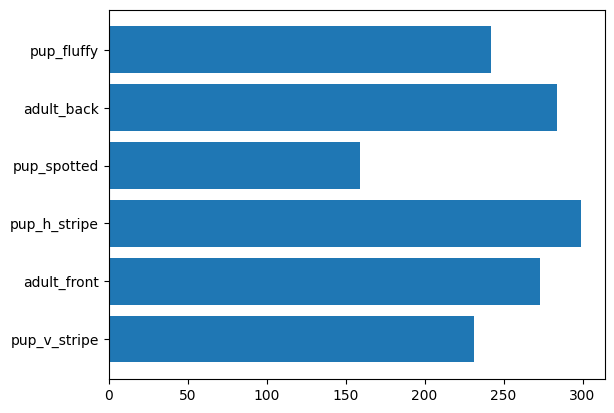

In [32]:
plt.barh(class_counts.keys(), class_counts.values())